<a href="https://www.kaggle.com/code/sonawanelalitsunil/2025-nvidia-stock-analysis-and-trends?scriptVersionId=224804867" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nvidia-stocks-data-2025/NVDA.csv



<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 "2025 NVIDIA Stock Analysis and Trends"  🚀


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Import dependancies  🚀

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Import dataset 🚀

In [3]:
df = pd.read_csv("/kaggle/input/nvidia-stocks-data-2025/NVDA.csv")

In [4]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-22,0.037615,0.041016,0.048828,0.038802,0.043750,2714688000
1,1999-01-25,0.041556,0.045313,0.045833,0.041016,0.044271,510480000
2,1999-01-26,0.038331,0.041797,0.046745,0.041146,0.045833,343200000
3,1999-01-27,0.038212,0.041667,0.042969,0.039583,0.041927,244368000
4,1999-01-28,0.038092,0.041536,0.041927,0.041276,0.041667,227520000


In [5]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume
6553,2025-02-10,133.570007,133.570007,135.000000,129.960007,130.089996,216989100
6554,2025-02-11,132.800003,132.800003,134.479996,131.020004,132.580002,178902400
6555,2025-02-12,131.139999,131.139999,132.240005,129.080002,130.020004,160278600
6556,2025-02-13,135.289993,135.289993,136.500000,131.169998,131.559998,197430000
6557,2025-02-14,138.850006,138.850006,139.250000,135.500000,136.479996,194892300


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6558 non-null   object 
 1   Adj Close  6558 non-null   float64
 2   Close      6558 non-null   float64
 3   High       6558 non-null   float64
 4   Low        6558 non-null   float64
 5   Open       6558 non-null   float64
 6   Volume     6558 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 358.8+ KB


In [7]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,6558.000000,6558.000000,6558.000000,6558.000000,6558.000000,6.558000e+03
mean,8.768532,8.795447,8.956567,8.618315,8.795850,5.991103e+08
std,23.907205,23.904882,24.349618,23.419200,23.922708,4.307236e+08
min,0.031286,0.034115,0.035547,0.033333,0.034896,1.968000e+07
25%,0.257739,0.281042,0.288511,0.273354,0.280810,3.384780e+08
50%,0.437176,0.466083,0.472875,0.459250,0.466584,5.002635e+08
75%,4.597059,4.644625,4.724000,4.588750,4.632437,7.307002e+08
max,149.429993,149.429993,153.130005,147.820007,153.029999,9.230856e+09


In [8]:
df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [9]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [10]:
pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import mplfinance as mpf

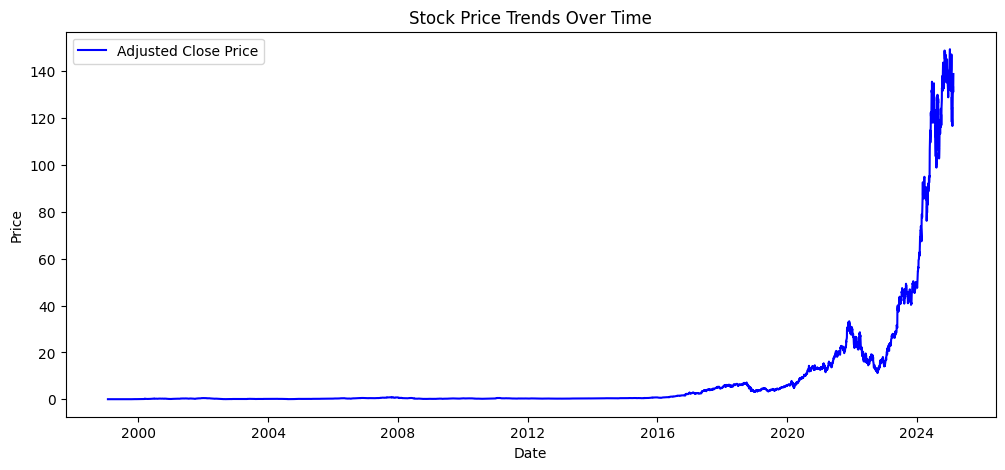

In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

# 1. Stock Price Trends Over Time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Adj Close"], label="Adjusted Close Price", color="blue")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Trends Over Time")
plt.legend()
plt.show()

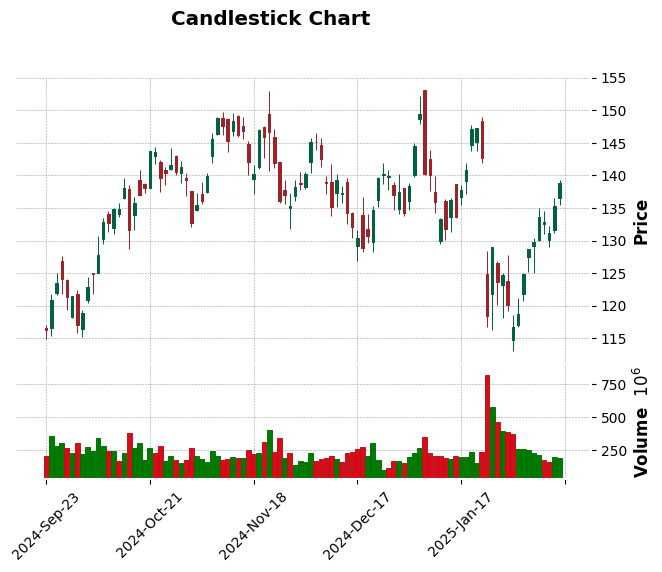

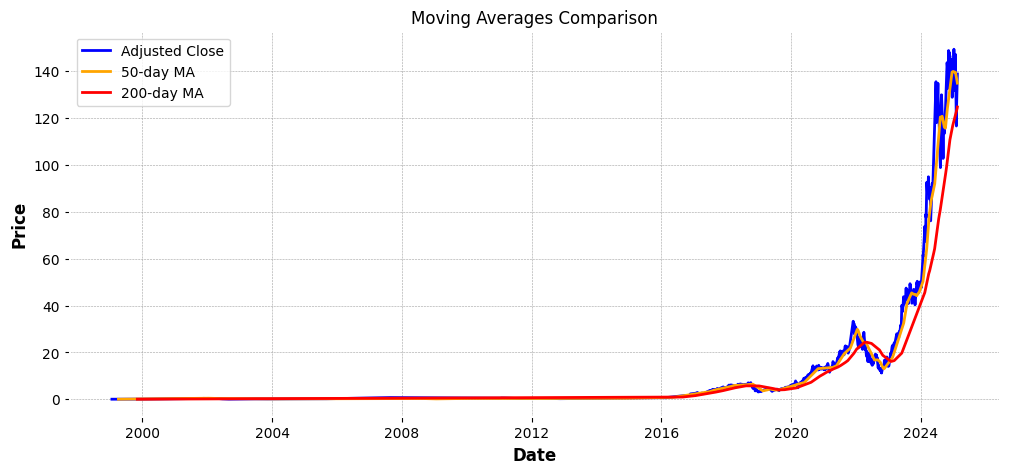

In [13]:
# 2. Candlestick Chart (High, Low, Open, Close)
mpf.plot(df.tail(100), type="candle", style="charles", volume=True, title="Candlestick Chart")

# 3. Moving Averages (50-day & 200-day)
df["MA50"] = df["Adj Close"].rolling(window=50).mean()
df["MA200"] = df["Adj Close"].rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Adj Close"], label="Adjusted Close", color="blue")
plt.plot(df.index, df["MA50"], label="50-day MA", color="orange")
plt.plot(df.index, df["MA200"], label="200-day MA", color="red")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Moving Averages Comparison")
plt.legend()
plt.show()

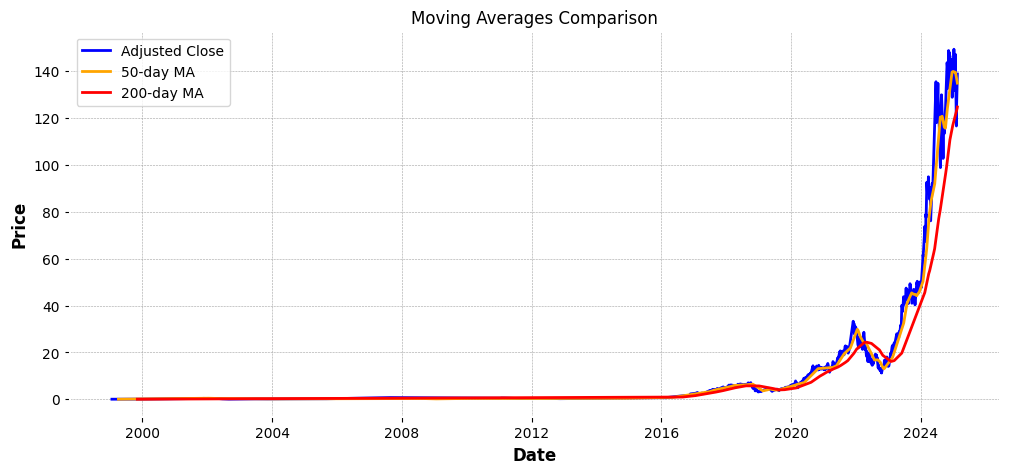

In [14]:
# 3. Moving Averages (50-day & 200-day)
df["MA50"] = df["Adj Close"].rolling(window=50).mean()
df["MA200"] = df["Adj Close"].rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Adj Close"], label="Adjusted Close", color="blue")
plt.plot(df.index, df["MA50"], label="50-day MA", color="orange")
plt.plot(df.index, df["MA200"], label="200-day MA", color="red")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Moving Averages Comparison")
plt.legend()
plt.show()

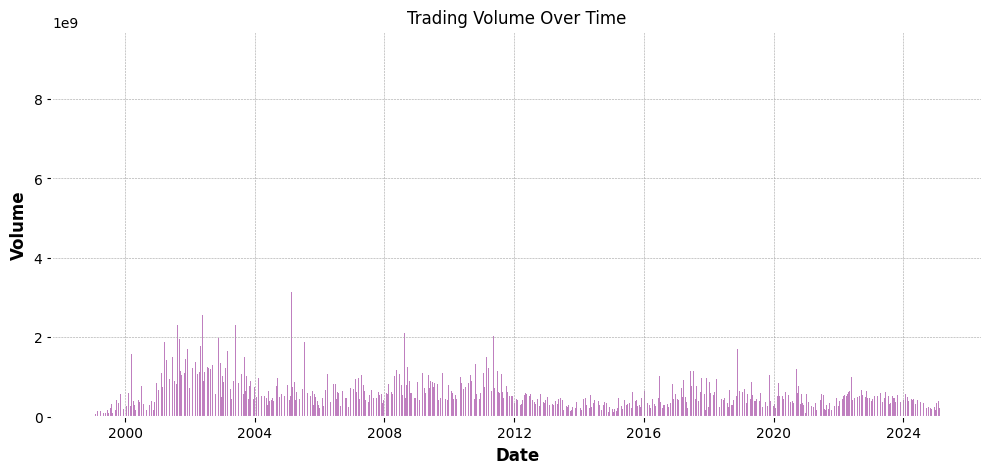

In [15]:
# 4. Trading Volume Over Time
plt.figure(figsize=(12, 5))
plt.bar(df.index, df["Volume"], color="purple", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("Trading Volume Over Time")
plt.show()

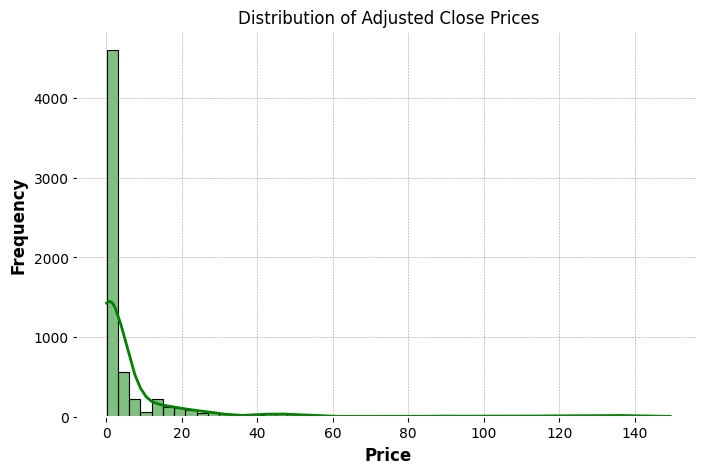

In [16]:
# 5. Price Distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df["Adj Close"], bins=50, kde=True, color="green")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Adjusted Close Prices")
plt.show()


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 EDA  🚀

In [17]:
X = df[["Open", "High", "Low", "Volume"]]
y=df["Close"]

In [18]:
from sklearn.preprocessing import MinMaxScaler


scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(X)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=537)

In [20]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(max_iter=10000),
    "ElasticNet Regression": ElasticNet(max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(n_estimators=100, random_state=42),
    "Extra Trees Regressor": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
}


In [21]:
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
results={}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train,y_train)
    end_time = time.time()
    y_pred=model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    train_time = end_time - start_time
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2, "Training Time (s)": train_time}

In [23]:
results_df = pd.DataFrame(results).T

In [24]:
import pandas as pd

results_df = pd.DataFrame(results).T  # Transpose for better structure
print(results_df)

                                MAE         MSE       RMSE  R2 Score  \
Linear Regression          0.080341    0.094662   0.307672  0.999839   
Lasso Regression           0.123431    0.169101   0.411218  0.999712   
ElasticNet Regression      0.118249    0.154090   0.392542  0.999738   
Random Forest              0.112131    0.166166   0.407635  0.999717   
Gradient Boosting          0.144767    0.200737   0.448037  0.999658   
AdaBoost Regressor         2.134196    5.185761   2.277227  0.991169   
Extra Trees Regressor      0.104615    0.147782   0.384425  0.999748   
XGBoost Regressor          0.230774    0.834200   0.913346  0.998579   
Support Vector Regressor   8.947584  661.369884  25.717113 -0.126229   
K-Nearest Neighbors       13.013694  657.503577  25.641833 -0.119645   
Decision Tree              0.140014    0.222315   0.471503  0.999621   

                          Training Time (s)  
Linear Regression                  0.040689  
Lasso Regression                   0.194080

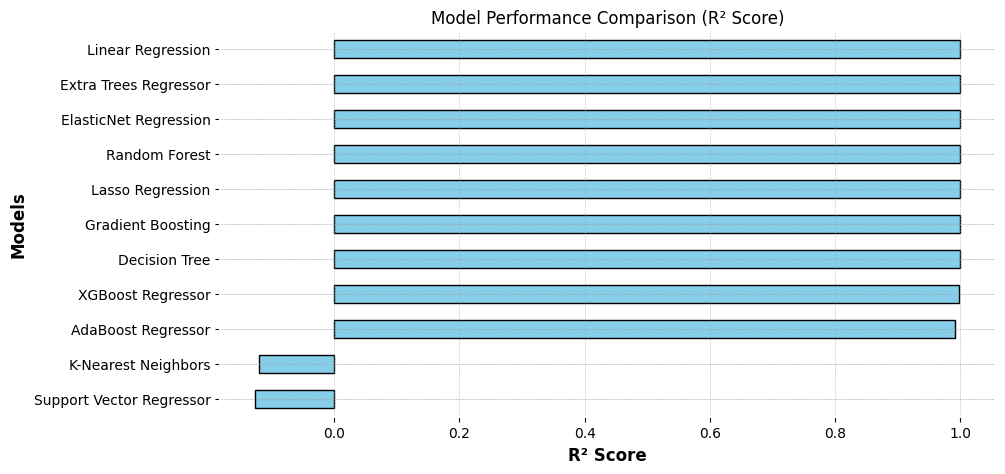

In [25]:
plt.figure(figsize=(10,5))
results_df["R2 Score"].sort_values().plot(kind="barh", color="skyblue", edgecolor="black")
plt.xlabel("R² Score")
plt.ylabel("Models")
plt.title("Model Performance Comparison (R² Score)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

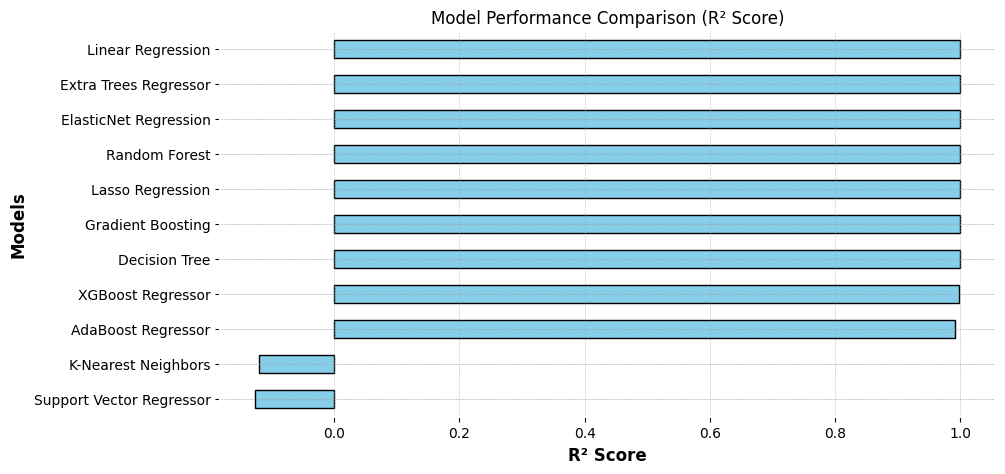

In [26]:
plt.figure(figsize=(10,5))
results_df["R2 Score"].sort_values().plot(kind="barh", color="skyblue", edgecolor="black")
plt.xlabel("R² Score")
plt.ylabel("Models")
plt.title("Model Performance Comparison (R² Score)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# Thank you!!!